In [1]:
# Task 3: Jurisdiction-Aware AI Fair Lending Monitoring Tool
#This notebook implements a prototype RegTech tool for monitoring fairness and compliance risks in AI-driven credit scoring.
#The prototype uses the German Credit Dataset with synthetic jurisdiction and demographic augmentation. It trains a logistic regression credit model, evaluates approval disparity by gender, applies US and EU jurisdiction-specific fairness thresholds, and generates compliance alerts for human review.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

np.random.seed(42)

In [3]:
# Load numeric German Credit Dataset
# Make sure german.data-numeric is in the same folder as this notebook

df = pd.read_csv("data/german.data-numeric", sep=r"\s+", header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
0,1,6,4,12,5,5,3,4,1,67,...,0,0,1,0,0,1,0,0,1,1
1,2,48,2,60,1,3,2,2,1,22,...,0,0,1,0,0,1,0,0,1,2
2,4,12,4,21,1,4,3,3,1,49,...,0,0,1,0,0,1,0,1,0,1
3,1,42,2,79,1,4,3,4,2,45,...,0,0,0,0,0,0,0,0,1,1
4,1,24,3,49,1,3,3,4,4,53,...,1,0,1,0,0,0,0,0,1,2


In [4]:
# The numeric version has 24 input variables + 1 target column
feature_cols = [f"feature_{i}" for i in range(1, 25)]
df.columns = feature_cols + ["credit_risk"]

df.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,...,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,feature_22,feature_23,feature_24,credit_risk
0,1,6,4,12,5,5,3,4,1,67,...,0,0,1,0,0,1,0,0,1,1
1,2,48,2,60,1,3,2,2,1,22,...,0,0,1,0,0,1,0,0,1,2
2,4,12,4,21,1,4,3,3,1,49,...,0,0,1,0,0,1,0,1,0,1
3,1,42,2,79,1,4,3,4,2,45,...,0,0,0,0,0,0,0,0,1,1
4,1,24,3,49,1,3,3,4,4,53,...,1,0,1,0,0,0,0,0,1,2


In [5]:
print("Dataset shape:", df.shape)
print(df["credit_risk"].value_counts())

# In German Credit Dataset:
# 1 = Good credit risk
# 2 = Bad credit risk

Dataset shape: (1000, 25)
credit_risk
1    700
2    300
Name: count, dtype: int64


In [6]:
# Convert target into binary format:
# good_credit = 1 means good credit risk
# good_credit = 0 means bad credit risk

df["good_credit"] = np.where(df["credit_risk"] == 1, 1, 0)

# Add synthetic jurisdiction variable: US or EU
df["jurisdiction"] = np.random.choice(["US", "EU"], size=len(df), p=[0.5, 0.5])

# German dataset contains sex/personal status in the original version.
# Since the numeric version does not preserve clear labels, we create a synthetic gender variable
# for fairness monitoring purposes only.

df["gender"] = np.random.choice(["Male", "Female"], size=len(df), p=[0.55, 0.45])

df.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,...,feature_19,feature_20,feature_21,feature_22,feature_23,feature_24,credit_risk,good_credit,jurisdiction,gender
0,1,6,4,12,5,5,3,4,1,67,...,0,0,1,0,0,1,1,1,US,Male
1,2,48,2,60,1,3,2,2,1,22,...,0,0,1,0,0,1,2,0,EU,Male
2,4,12,4,21,1,4,3,3,1,49,...,0,0,1,0,1,0,1,1,EU,Female
3,1,42,2,79,1,4,3,4,2,45,...,0,0,0,0,0,1,1,1,EU,Female
4,1,24,3,49,1,3,3,4,4,53,...,0,0,0,0,0,1,2,0,US,Female


In [7]:
X = df[feature_cols]
y = df["good_credit"]

X_train, X_test, y_train, y_test, df_train, df_test = train_test_split(
    X, y, df, test_size=0.3, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (700, 24)
Test size: (300, 24)


In [8]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('logreg', LogisticRegression(max_iter=1000))])

In [9]:
df_test = df_test.copy()

df_test["predicted_probability"] = model.predict_proba(X_test)[:, 1]
df_test["approval_decision"] = np.where(df_test["predicted_probability"] >= 0.5, 1, 0)

df_test[["predicted_probability", "approval_decision", "good_credit", "gender", "jurisdiction"]].head()

,predicted_probability,approval_decision,good_credit,gender,jurisdiction
80,0.924995,1,0,Female,EU
157,0.451618,0,1,Female,EU
65,0.959426,1,1,Female,EU
489,0.902798,1,1,Male,EU
804,0.400109,0,1,Male,US


In [10]:
y_pred = df_test["approval_decision"]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, df_test["predicted_probability"]))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7533333333333333
ROC-AUC: 0.7759788359788361

Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.48      0.54        90
           1       0.80      0.87      0.83       210

    accuracy                           0.75       300
   macro avg       0.70      0.67      0.68       300
weighted avg       0.74      0.75      0.74       300



In [11]:
# Introduce a small synthetic approval bias for demonstration.
# This simulates a scenario where female applicants face slightly lower approval probability.

df_test["adjusted_probability"] = df_test["predicted_probability"]

df_test.loc[df_test["gender"] == "Female", "adjusted_probability"] -= 0.2

# Keep probability within [0, 1]
df_test["adjusted_probability"] = df_test["adjusted_probability"].clip(0, 1)

df_test["approval_decision"] = np.where(df_test["adjusted_probability"] >= 0.5, 1, 0)

df_test.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,...,feature_22,feature_23,feature_24,credit_risk,good_credit,jurisdiction,gender,predicted_probability,approval_decision,adjusted_probability
80,4,24,2,59,5,2,2,1,3,44,...,0,0,1,2,0,EU,Female,0.924995,1,0.724995
157,1,12,1,3,1,5,4,1,3,45,...,0,1,0,1,1,EU,Female,0.451618,0,0.251618
65,4,27,2,52,5,5,3,4,2,48,...,0,0,1,1,1,EU,Female,0.959426,1,0.759426
489,4,6,2,35,1,3,3,3,2,26,...,0,0,1,1,1,EU,Male,0.902798,1,0.902798
804,2,12,2,75,5,1,2,2,1,24,...,1,0,0,1,1,US,Male,0.400109,0,0.400109


In [12]:
approval_by_gender = df_test.groupby("gender")["approval_decision"].mean()

approval_by_gender

gender
Female    0.671533
Male      0.742331
Name: approval_decision, dtype: float64

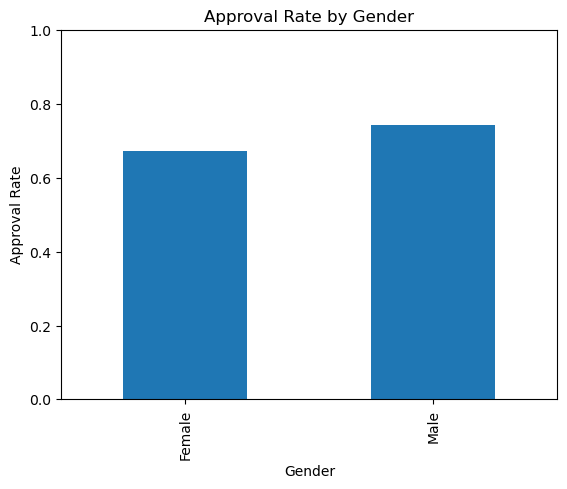

In [13]:
approval_by_gender.plot(kind="bar")
plt.title("Approval Rate by Gender")
plt.ylabel("Approval Rate")
plt.xlabel("Gender")
plt.ylim(0, 1)
plt.show()

In [14]:
male_approval = approval_by_gender.get("Male", np.nan)
female_approval = approval_by_gender.get("Female", np.nan)

approval_disparity = abs(male_approval - female_approval)

print("Male Approval Rate:", round(male_approval, 3))
print("Female Approval Rate:", round(female_approval, 3))
print("Approval Rate Disparity:", round(approval_disparity, 3))

Male Approval Rate: 0.742
Female Approval Rate: 0.672
Approval Rate Disparity: 0.071


In [15]:
def false_positive_rate(group):
    # False positive: model approves applicant, but actual credit risk is bad
    fp = ((group["approval_decision"] == 1) & (group["good_credit"] == 0)).sum()
    tn = ((group["approval_decision"] == 0) & (group["good_credit"] == 0)).sum()
    
    if fp + tn == 0:
        return np.nan
    return fp / (fp + tn)

fpr_by_gender = df_test.groupby("gender")[["approval_decision", "good_credit"]].apply(false_positive_rate)

fpr_by_gender

gender
Female    0.361111
Male      0.481481
dtype: float64

In [16]:
jurisdiction_rules = {
    "US": {
        "approval_disparity_threshold": 0.10,
        "requires_explainability": True,
        "main_focus": "Adverse action explanation and fair lending monitoring"
    },
    "EU": {
        "approval_disparity_threshold": 0.05,
        "requires_explainability": True,
        "main_focus": "High-risk AI bias testing and governance oversight"
    }
}

jurisdiction_rules

{'US': {'approval_disparity_threshold': 0.1,
  'requires_explainability': True,
  'main_focus': 'Adverse action explanation and fair lending monitoring'},
 'EU': {'approval_disparity_threshold': 0.05,
  'requires_explainability': True,
  'main_focus': 'High-risk AI bias testing and governance oversight'}}

In [17]:
def compliance_check(jurisdiction, disparity):
    threshold = jurisdiction_rules[jurisdiction]["approval_disparity_threshold"]
    
    if disparity > threshold:
        status = "Breach"
        alert = "Fairness risk detected. Human review required."
    else:
        status = "Pass"
        alert = "No material fairness alert under current threshold."
    
    return pd.Series({
        "jurisdiction": jurisdiction,
        "threshold": threshold,
        "approval_disparity": disparity,
        "status": status,
        "alert": alert,
        "main_focus": jurisdiction_rules[jurisdiction]["main_focus"]
    })

compliance_results = pd.DataFrame([
    compliance_check("US", approval_disparity),
    compliance_check("EU", approval_disparity)
])

compliance_results

,jurisdiction,threshold,approval_disparity,status,alert,main_focus
0,US,0.10,0.070798,Pass,No material fairness alert under current thres...,Adverse action explanation and fair lending mo...
1,EU,0.05,0.070798,Breach,Fairness risk detected. Human review required.,High-risk AI bias testing and governance overs...


In [18]:
for _, row in compliance_results.iterrows():
    print("Jurisdiction:", row["jurisdiction"])
    print("Main Focus:", row["main_focus"])
    print("Approval Disparity:", round(row["approval_disparity"], 3))
    print("Threshold:", row["threshold"])
    print("Status:", row["status"])
    print("Alert:", row["alert"])
    print("-" * 50)

Jurisdiction: US
Main Focus: Adverse action explanation and fair lending monitoring
Approval Disparity: 0.071
Threshold: 0.1
Status: Pass
Alert: No material fairness alert under current threshold.
--------------------------------------------------
Jurisdiction: EU
Main Focus: High-risk AI bias testing and governance oversight
Approval Disparity: 0.071
Threshold: 0.05
Status: Breach
Alert: Fairness risk detected. Human review required.
--------------------------------------------------


In [19]:
thresholds = np.arange(0.01, 0.16, 0.01)

sensitivity = pd.DataFrame({
    "threshold": thresholds,
    "breach": thresholds < approval_disparity
})

sensitivity

,threshold,breach
0,0.01,True
1,0.02,True
2,0.03,True
3,0.04,True
4,0.05,True
5,0.06,True
6,0.07,True
7,0.08,False
8,0.09,False
9,0.10,False


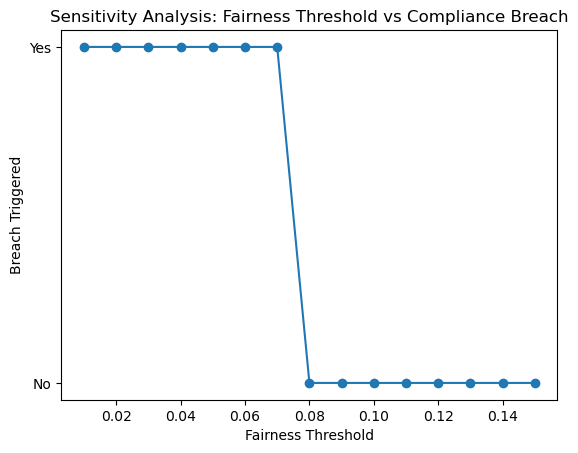

In [20]:
plt.plot(sensitivity["threshold"], sensitivity["breach"].astype(int), marker="o")
plt.title("Sensitivity Analysis: Fairness Threshold vs Compliance Breach")
plt.xlabel("Fairness Threshold")
plt.ylabel("Breach Triggered")
plt.yticks([0, 1], ["No", "Yes"])
plt.show()

In [21]:
df_test.to_csv("synthetic_augmented_credit_dataset.csv", index=False)

compliance_results.to_csv("jurisdiction_compliance_results.csv", index=False)

print("Files saved:")
print("synthetic_augmented_credit_dataset.csv")
print("jurisdiction_compliance_results.csv")

Files saved:
synthetic_augmented_credit_dataset.csv
jurisdiction_compliance_results.csv


In [22]:
import shap

/var/folders/90/3g5kdnq52ggg_pr8dr7nnslh0000gn/T/ipykernel_4008/3891830218.py:10: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_scaled, feature_names=feature_cols)


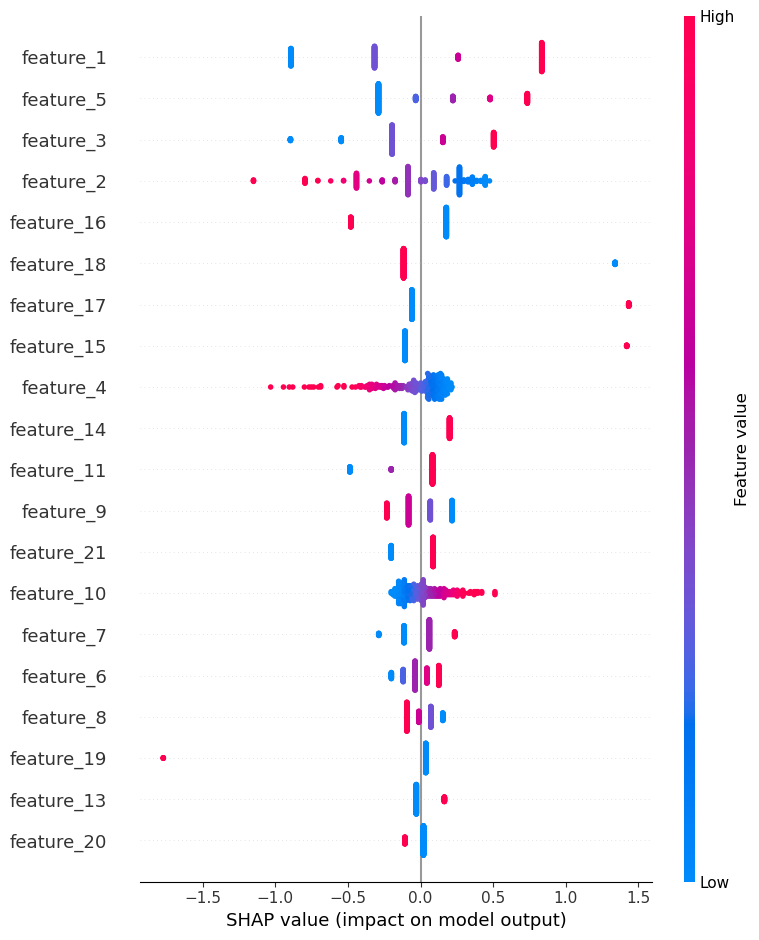

In [23]:
# Prepare transformed data from the pipeline
scaler = model.named_steps["scaler"]
logreg = model.named_steps["logreg"]

X_test_scaled = scaler.transform(X_test)

explainer = shap.LinearExplainer(logreg, X_test_scaled)
shap_values = explainer.shap_values(X_test_scaled)

shap.summary_plot(shap_values, X_test_scaled, feature_names=feature_cols)

In [24]:
model_card = {
    "Model": "Logistic Regression Credit Scoring Model",
    "Purpose": "Predict good credit risk and support fair lending monitoring",
    "Dataset": "German Credit Dataset with synthetic jurisdiction and demographic augmentation",
    "Jurisdictions": ["US", "EU"],
    "Fairness Metrics": ["Approval rate disparity", "False positive rate gap"],
    "Explainability Method": "SHAP",
    "Limitations": [
        "Synthetic demographic augmentation may not represent real lending populations",
        "Model does not replace legal or compliance judgement",
        "Jurisdiction thresholds are simplified for prototype demonstration",
        "Fairness metrics do not prove causal discrimination"
    ],
    "Human Oversight": "Compliance officers must review fairness alerts before operational action"
}

model_card

{'Model': 'Logistic Regression Credit Scoring Model',
 'Purpose': 'Predict good credit risk and support fair lending monitoring',
 'Dataset': 'German Credit Dataset with synthetic jurisdiction and demographic augmentation',
 'Jurisdictions': ['US', 'EU'],
 'Fairness Metrics': ['Approval rate disparity', 'False positive rate gap'],
 'Explainability Method': 'SHAP',
 'Limitations': ['Synthetic demographic augmentation may not represent real lending populations',
  'Model does not replace legal or compliance judgement',
  'Jurisdiction thresholds are simplified for prototype demonstration',
  'Fairness metrics do not prove causal discrimination'],
 'Human Oversight': 'Compliance officers must review fairness alerts before operational action'}